In [4]:
import numpy as np 
import pandas as pd 
import librosa
import librosa.display
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
import seaborn as sns
import IPython
import tensorflow.keras.layers as L
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder,StandardScaler
import re
import itertools
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import os

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/lazy_loader/__init__.py:202: RuntimeWarning: subpackages can technically be lazily loaded, but it causes the package to be eagerly loaded even if it is already lazily loaded.So, you probably shouldn't use subpackages with this lazy feature.
  warnings.warn(msg, RuntimeWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/lazy_loader/__init__.py:202: RuntimeWarning: subpackages can technically be lazily loaded, but it causes the package to be eagerly loaded even if it is already lazily loaded.So, you probably shouldn't use subpackages with this lazy feature.
  warnings.warn(msg, RuntimeWarning)


In [5]:
Crema_Path='./uploads/Crema/'
Ravdess_Path='./uploads/Ravdess/audio_speech_actors_01-24'
Savee_Path='./uploads/Savee/'
Tess_Path='./uploads/Tess/'

In [6]:
crema=[]
for wav in os.listdir(Crema_Path):
    emotion=wav.partition(".wav")[0].split('_')
    if emotion[2]=='SAD':
        crema.append(('sad',Crema_Path+'/'+wav))
    elif emotion[2]=='ANG':
        crema.append(('angry',Crema_Path+'/'+wav))
    elif emotion[2]=='DIS':
        crema.append(('disgust',Crema_Path+'/'+wav))
    elif emotion[2]=='FEA':
        crema.append(('fear',Crema_Path+'/'+wav))
    elif emotion[2]=='HAP':
        crema.append(('happy',Crema_Path+'/'+wav))
    elif emotion[2]=='NEU':
        crema.append(('neutral',Crema_Path+'/'+wav))
    else:
        crema.append(('unknown',Crema_Path+'/'+wav))
Crema_df=pd.DataFrame.from_dict(crema)
Crema_df.rename(columns={0:'Emotion',1:'File_Path'},inplace=True)
Crema_df.head()

,Emotion,File_Path
0,angry,./uploads/Crema//1022_ITS_ANG_XX.wav
1,angry,./uploads/Crema//1037_ITS_ANG_XX.wav
2,neutral,./uploads/Crema//1060_ITS_NEU_XX.wav
3,neutral,./uploads/Crema//1075_ITS_NEU_XX.wav
4,disgust,./uploads/Crema//1073_IOM_DIS_XX.wav


In [7]:
Crema_df['Emotion'].unique()

array(['angry', 'neutral', 'disgust', 'sad', 'fear', 'happy'],
      dtype=object)

In [57]:
savee=[]
if os.path.exists(Savee_Path):
    for wav in os.listdir(Savee_Path):
        emo=wav.partition('.wav')[0].split('_')[1].replace(r'[0-9]','')
        emotion=re.split(r'[0-9]',emo)[0]
        if emotion=='a':
            savee.append(('angry',Savee_Path+'/'+wav))
        elif emotion=='d':
            savee.append(('disgust',Savee_Path+'/'+wav))
        elif emotion=='f':
            savee.append(('fear',Savee_Path+'/'+wav))
        elif emotion=='h':
            savee.append(('happy',Savee_Path+'/'+wav))
        elif emotion=='n':
            savee.append(('neutral',Savee_Path+'/'+wav))
        elif emotion=='sa':
            savee.append(('sad',Savee_Path+'/'+wav))
        elif emotion=='su':
            savee.append(('surprise',Savee_Path+'/'+wav))
Savee_df=pd.DataFrame(savee, columns=['Emotion','File_Path']) if savee else pd.DataFrame(columns=['Emotion','File_Path'])
print(f"Savee dataset loaded: {len(Savee_df)} files")
Savee_df.head()

Savee dataset loaded: 0 files


,Emotion,File_Path


In [58]:
Savee_df['Emotion'].unique()

array([], dtype=object)

In [59]:
tess=[]
if os.path.exists(Tess_Path):
    for directory in os.listdir(Tess_Path):
        for wav in os.listdir(os.path.join(Tess_Path,directory)):
            emotion=wav.partition('.wav')[0].split('_')
            if emotion[2]=='ps':
                tess.append(('surprise',os.path.join(Tess_Path,directory,wav)))
            else:
                tess.append((emotion[2],os.path.join(Tess_Path,directory,wav)))
Tess_df=pd.DataFrame(tess, columns=['Emotion','File_Path']) if tess else pd.DataFrame(columns=['Emotion','File_Path'])
print(f"Tess dataset loaded: {len(Tess_df)} files")
Tess_df.head()

Tess dataset loaded: 0 files


,Emotion,File_Path


In [60]:
Tess_df['Emotion'].unique()

array([], dtype=object)

In [61]:
main_df=pd.concat([Crema_df,Ravdess_df,Savee_df,Tess_df],axis=0)
main_df.shape

(7442, 2)

In [62]:
main_df.head(15)

,Emotion,File_Path
0,angry,./uplods/Crema//1022_ITS_ANG_XX.wav
1,angry,./uplods/Crema//1037_ITS_ANG_XX.wav
2,neutral,./uplods/Crema//1060_ITS_NEU_XX.wav
3,neutral,./uplods/Crema//1075_ITS_NEU_XX.wav
4,disgust,./uplods/Crema//1073_IOM_DIS_XX.wav
5,disgust,./uplods/Crema//1066_IOM_DIS_XX.wav
6,sad,./uplods/Crema//1078_IWL_SAD_XX.wav
7,fear,./uplods/Crema//1029_TAI_FEA_XX.wav
8,sad,./uplods/Crema//1039_IEO_SAD_MD.wav
9,happy,./uplods/Crema//1008_TAI_HAP_XX.wav


In [63]:
main_df.tail(15)

,Emotion,File_Path
7427,sad,./uplods/Crema//1045_IWW_SAD_XX.wav
7428,sad,./uplods/Crema//1050_IWW_SAD_XX.wav
7429,angry,./uplods/Crema//1089_DFA_ANG_XX.wav
7430,sad,./uplods/Crema//1079_TIE_SAD_XX.wav
7431,disgust,./uplods/Crema//1068_WSI_DIS_XX.wav
7432,neutral,./uplods/Crema//1067_IWW_NEU_XX.wav
7433,fear,./uplods/Crema//1078_ITH_FEA_XX.wav
7434,neutral,./uplods/Crema//1072_IWW_NEU_XX.wav
7435,happy,./uplods/Crema//1059_ITH_HAP_XX.wav
7436,disgust,./uplods/Crema//1068_DFA_DIS_XX.wav


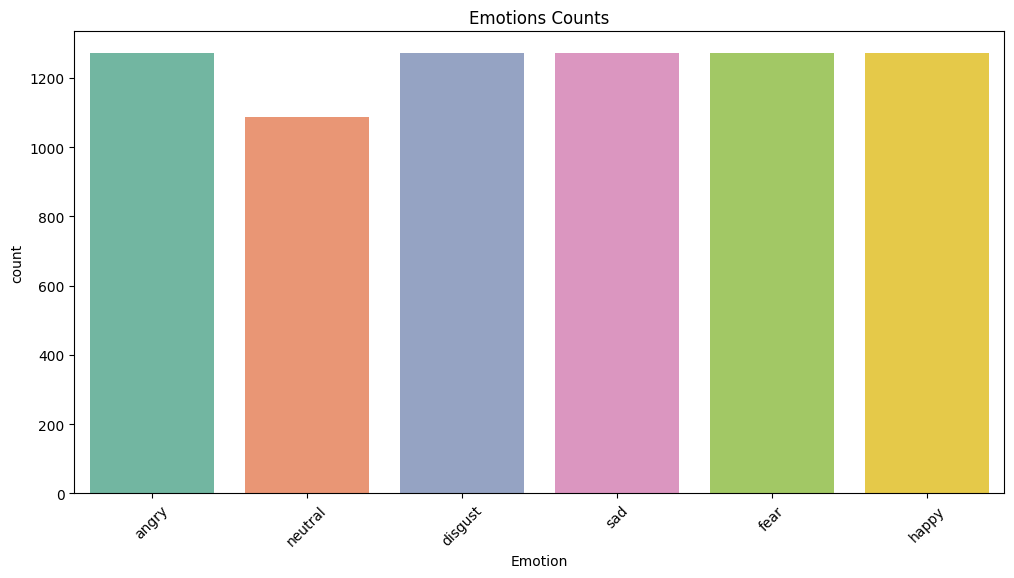

In [64]:
plt.figure(figsize=(12,6))
plt.title('Emotions Counts')
emotions=sns.countplot(x='Emotion',data=main_df,palette='Set2')
emotions.set_xticklabels(emotions.get_xticklabels(),rotation=45)
plt.show()

In [35]:
emotion_names=np.array(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad'])

In [ ]:
colors={'disgust':'#804E2D','happy':'#F19C0E','sad':'#478FB8','neutral':'#4CB847','fear':'#7D55AA','angry':'#C00808','surprise':'#EE00FF'}

In [ ]:
def wave_plot(data,sr,emotion,color):
    plt.figure(figsize=(12,5))
    plt.title(f'{emotion} emotion for waveplot',size=17)
    librosa.display.waveshow(y=data,sr=sr,color=color)

In [68]:
def spectogram(data,sr,emotion):
    audio=librosa.stft(data)
    audio_db=librosa.amplitude_to_db(abs(audio))
    plt.figure(figsize=(12,5))
    plt.title(f'{emotion} emotion for spectogram',size=17)
    librosa.display.specshow(audio_db,sr=sr,x_axis='time',y_axis='hz')

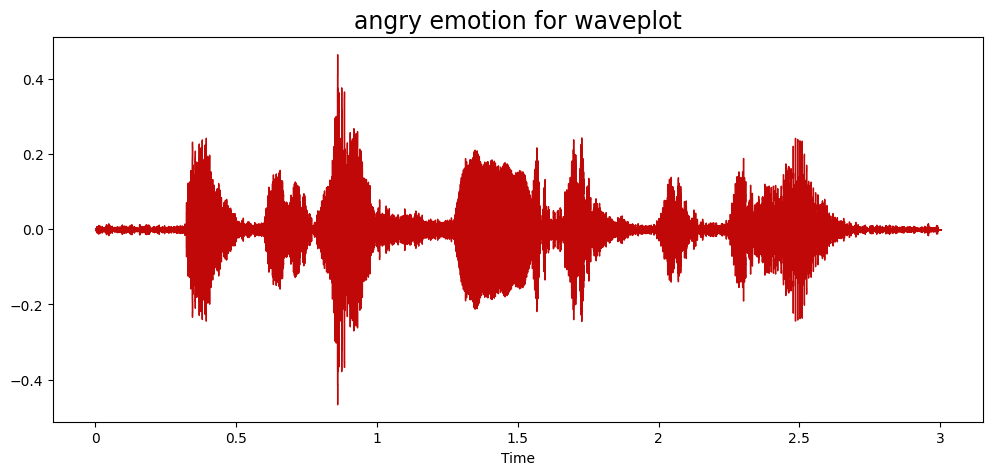

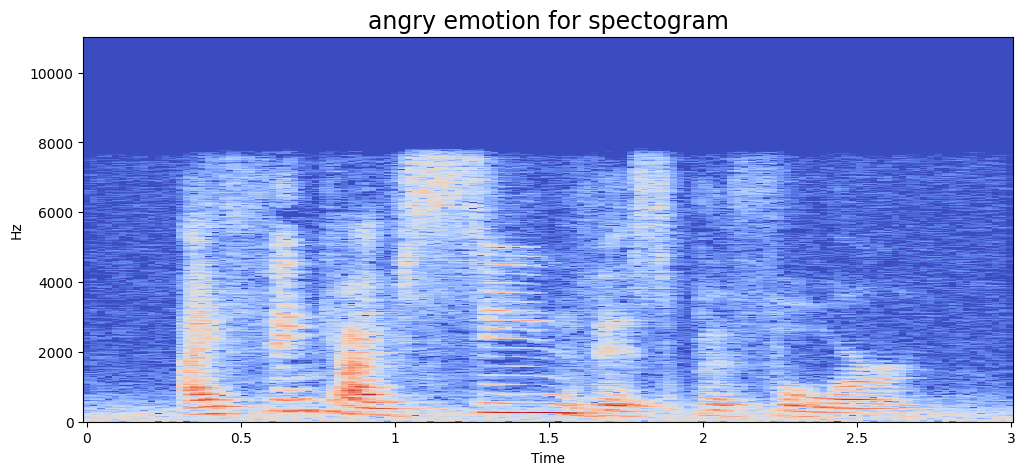

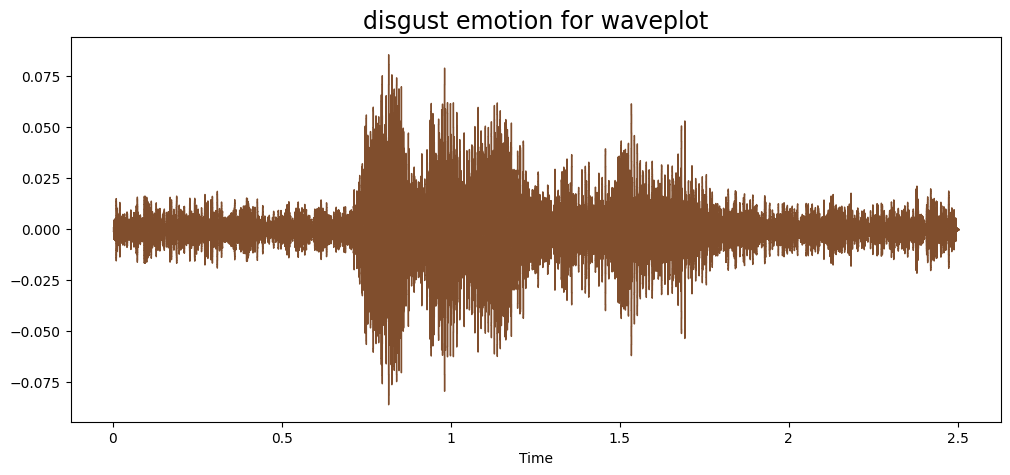

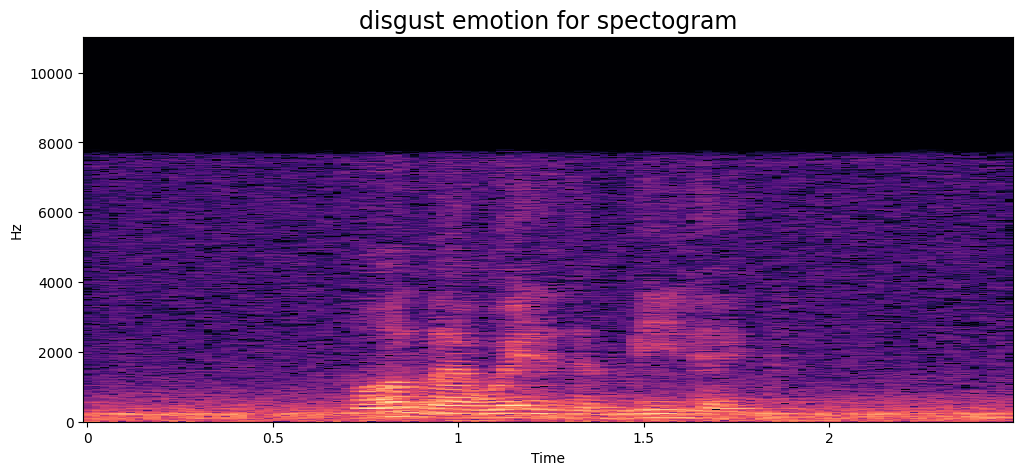

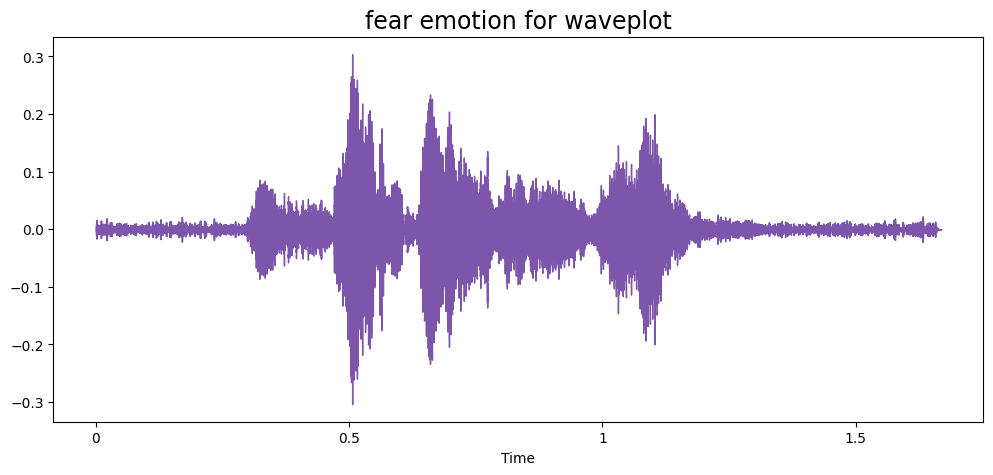

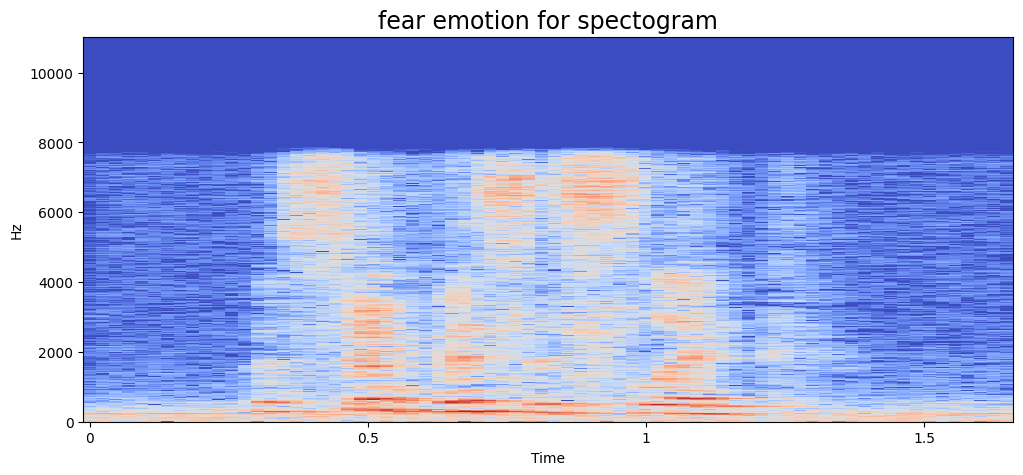

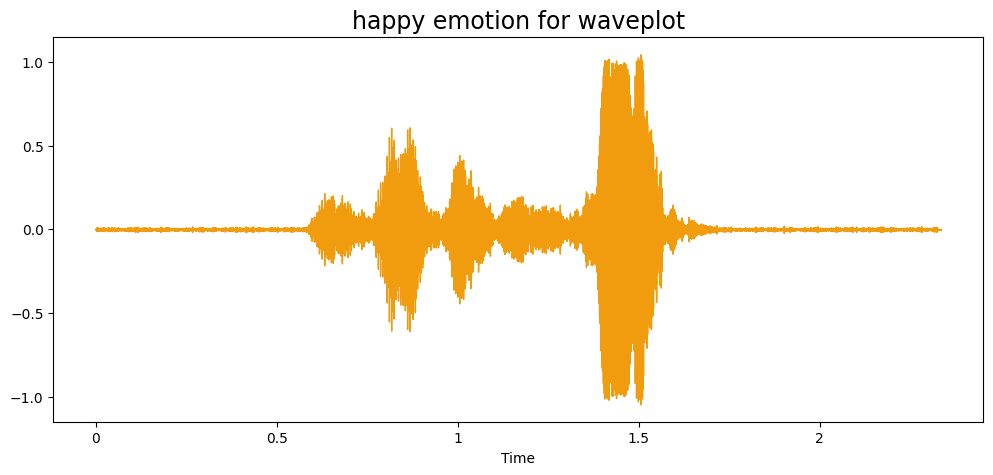

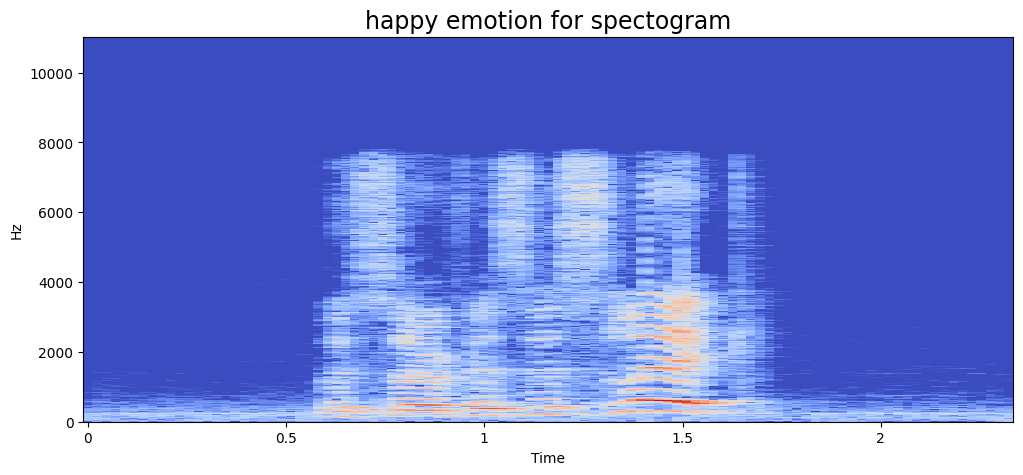

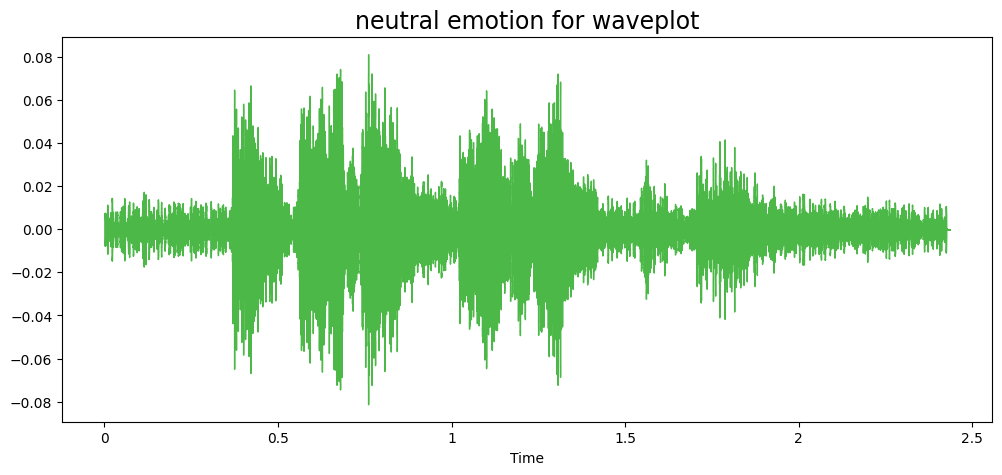

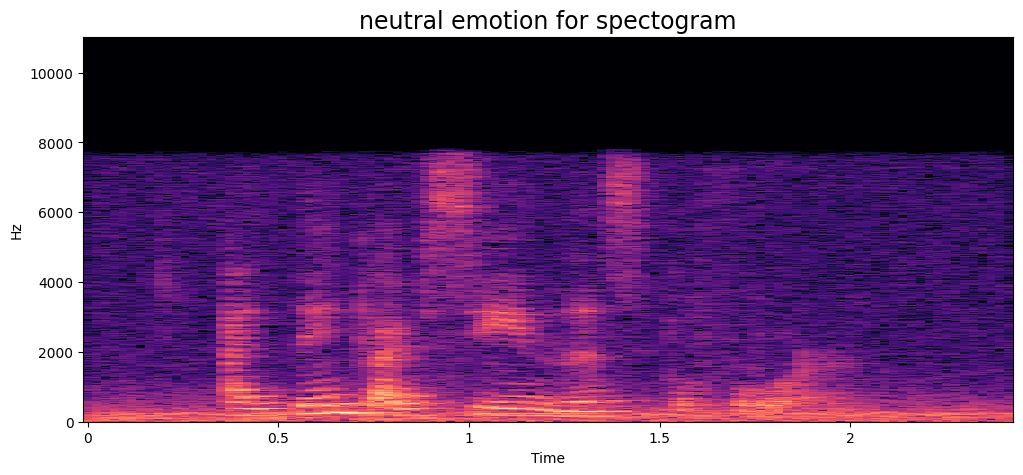

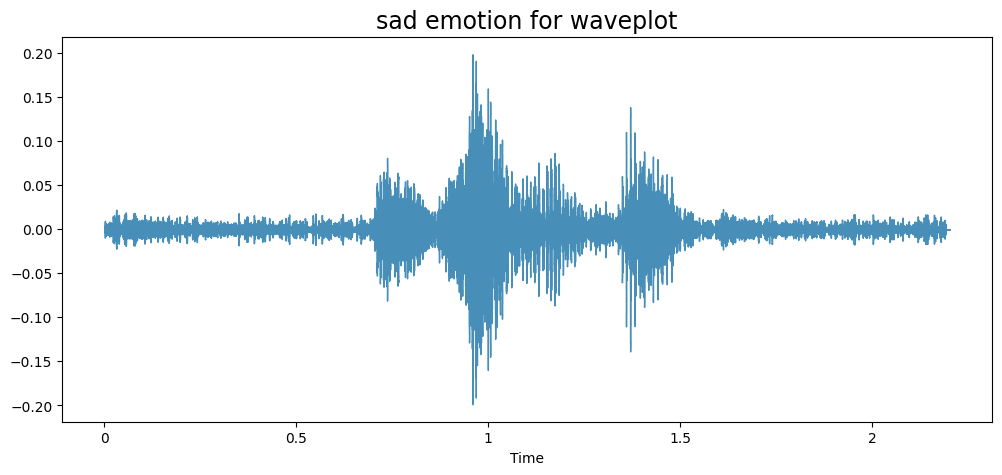

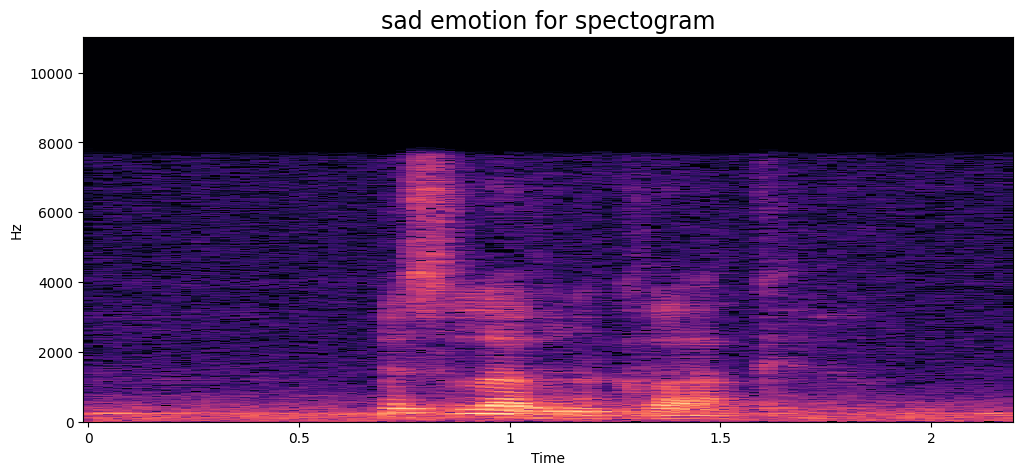

In [69]:
audio_path=[]
for emotion in emotion_names:
    path=np.array(main_df['File_Path'][main_df['Emotion']==emotion])[1]
    data,sr=librosa.load(path)
    wave_plot(data,sr,emotion,colors[emotion])
    spectogram(data,sr,emotion)
    audio_path.append(path)

In [70]:
print('Disgust Audio Sample\n')
IPython.display.Audio(audio_path[0])

Disgust Audio Sample



In [71]:
print('Happy Audio Sample\n')
IPython.display.Audio(audio_path[1])

Happy Audio Sample



In [72]:
print('Sad Audio Sample\n')
IPython.display.Audio(audio_path[2])

Sad Audio Sample



In [73]:
print('Neutral Audio Sample\n')
IPython.display.Audio(audio_path[3])

Neutral Audio Sample



In [74]:
print('Fear Audio Sample\n')
IPython.display.Audio(audio_path[4])

Fear Audio Sample



In [75]:
print('Angry Audio Sample\n')
IPython.display.Audio(audio_path[5])

Angry Audio Sample



In [76]:
if len(audio_path) > 6:
    print('Surprise Audio Sample\n')
    IPython.display.Audio(audio_path[6])
else:
    print('Surprise emotion not available in dataset')

Surprise emotion not available in dataset


In [77]:
def add_noise(data,random=False,rate=0.035,threshold=0.075):
    if random:
        rate=np.random.random()*threshold
    noise=rate*np.random.uniform()*np.amax(data)
    augmented_data=data+noise*np.random.normal(size=data.shape[0])
    return augmented_data

def shifting(data,rate=1000):
    augmented_data=int(np.random.uniform(low=-5,high=5)*rate)
    augmented_data=np.roll(data,augmented_data)
    return augmented_data

def pitching(data,sr,pitch_factor=0.7,random=False):
    if random:
        pitch_factor=np.random.random() * pitch_factor
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=pitch_factor)

def streching(data,rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

In [78]:
if len(audio_path) > 0:
    data,sr=librosa.load(audio_path[0])
else:
    print('No audio data available')

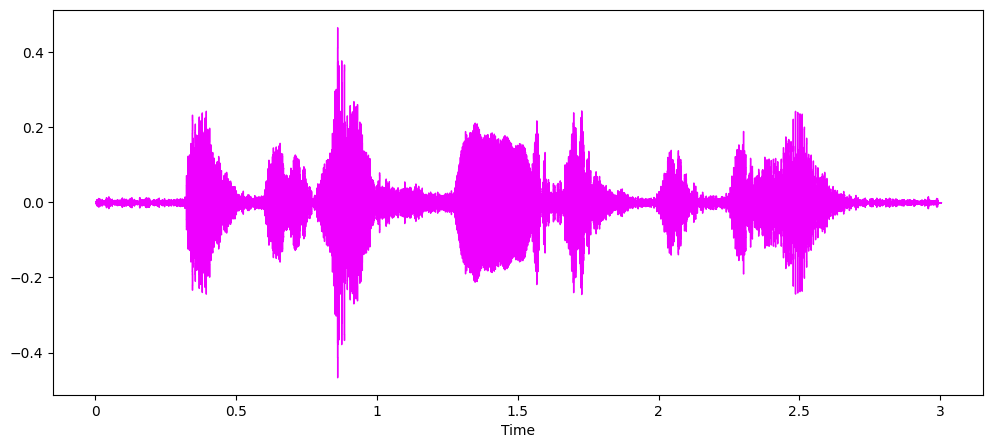

In [79]:
if len(audio_path) > 0:
    plt.figure(figsize=(12,5))
    librosa.display.waveshow(data, sr=sr, color='#EE00FF')
    IPython.display.Audio(audio_path[0], rate=sr)

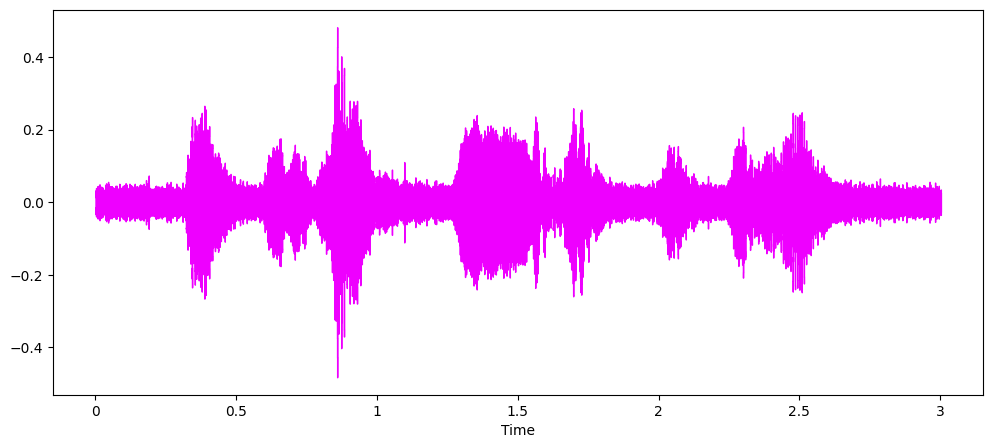

In [80]:
if len(audio_path) > 0:
    noised_audio=add_noise(data)
    plt.figure(figsize=(12,5))
    librosa.display.waveshow(noised_audio, sr=sr, color='#EE00FF')
    IPython.display.Audio(noised_audio,rate=sr)

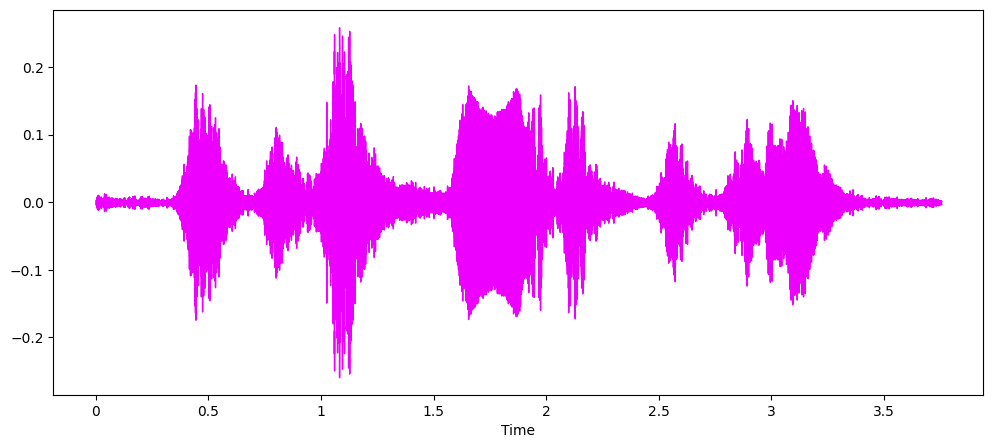

In [81]:
if len(audio_path) > 0:
    stretched_audio=streching(data)
    plt.figure(figsize=(12,5))
    librosa.display.waveshow(stretched_audio, sr=sr, color='#EE00FF')
    IPython.display.Audio(stretched_audio,rate=sr)

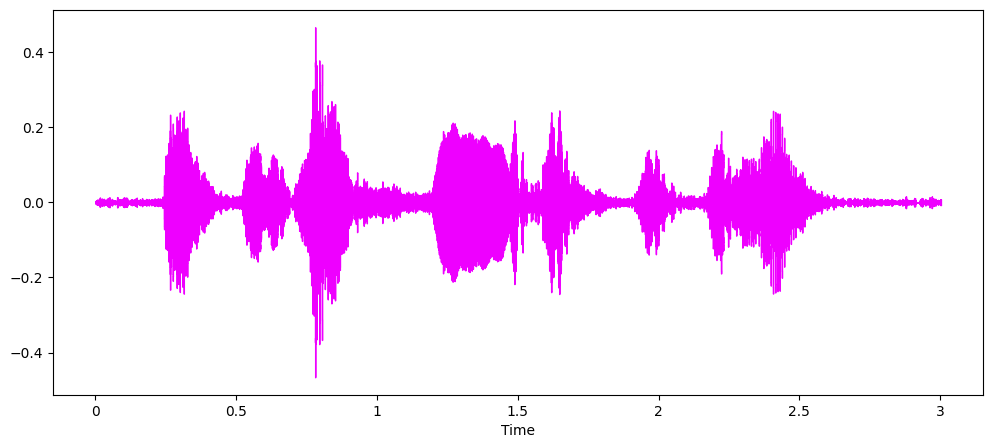

In [82]:
if len(audio_path) > 0:
    shifted_audio=shifting(data)
    plt.figure(figsize=(12,5))
    librosa.display.waveshow(shifted_audio, sr=sr, color='#EE00FF')
    IPython.display.Audio(shifted_audio,rate=sr)

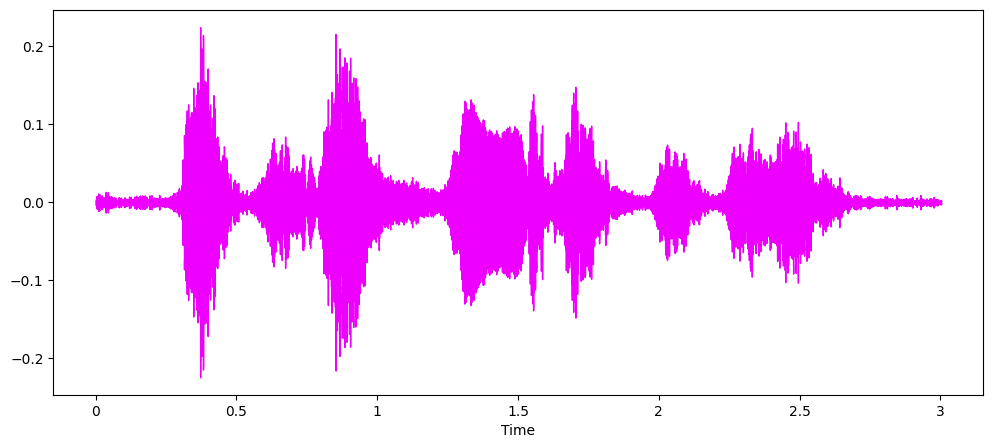

In [101]:
if len(audio_path) > 0:
    pitched_audio=pitching(data,sr)
    plt.figure(figsize=(12,5))
    librosa.display.waveshow(pitched_audio, sr=sr, color='#EE00FF')
    IPython.display.Audio(pitched_audio,rate=sr)

In [18]:
def zcr(data,frame_length,hop_length):
    zcr=librosa.feature.zero_crossing_rate(data,frame_length=frame_length,hop_length=hop_length)
    return np.squeeze(zcr)
def rmse(data,frame_length=2048,hop_length=512):
    rmse=librosa.feature.rms(y=data,frame_length=frame_length,hop_length=hop_length)
    return np.squeeze(rmse)
def mfcc(data,sr,frame_length=2048,hop_length=512,flatten:bool=True):
    mfcc=librosa.feature.mfcc(y=data,sr=sr)
    return np.squeeze(mfcc.T)if not flatten else np.ravel(mfcc.T)

def extract_features(data,sr,frame_length=2048,hop_length=512):
    result=np.array([])
    
    result=np.hstack((result,
                      zcr(data,frame_length,hop_length),
                      rmse(data,frame_length,hop_length),
                      mfcc(data,sr,frame_length,hop_length)
                     ))
    return result

def get_features(path,duration=2.5, offset=0.6):
    data,sr=librosa.load(path,duration=duration,offset=offset)
    aud=extract_features(data,sr)
    audio=np.array(aud)
    
    noised_audio=add_noise(data,random=True)
    aud2=extract_features(noised_audio,sr)
    audio=np.vstack((audio,aud2))
    
    pitched_audio=pitching(data,sr,random=True)
    aud3=extract_features(pitched_audio,sr)
    audio=np.vstack((audio,aud3))
    
    pitched_audio1=pitching(data,sr,random=True)
    pitched_noised_audio=add_noise(pitched_audio1,random=True)
    aud4=extract_features(pitched_noised_audio,sr)
    audio=np.vstack((audio,aud4))
    
    return audio

In [85]:
X,Y=[],[]
for path,emotion,index in zip(main_df.File_Path,main_df.Emotion,range(main_df.File_Path.shape[0])):
    features=get_features(path)
    if index%500==0:
        print(f'{index} audio has been processed')
    for i in features:
        X.append(i)
        Y.append(emotion)
print('Done')

0 audio has been processed
500 audio has been processed
1000 audio has been processed
1500 audio has been processed
2000 audio has been processed
2500 audio has been processed
3000 audio has been processed
3500 audio has been processed
4000 audio has been processed
4500 audio has been processed
5000 audio has been processed
5500 audio has been processed
6000 audio has been processed
6500 audio has been processed
7000 audio has been processed
Done


In [11]:
processed_data_path='./processed_data.csv'

In [87]:
extract=pd.DataFrame(X)
extract['Emotion']=Y
extract.to_csv(processed_data_path,index=False)
extract.head(10)

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotion
0,0.042480,0.082520,0.153320,0.232422,0.344727,0.437500,0.474609,0.417969,0.317871,0.216309,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
1,0.131348,0.197754,0.297852,0.358398,0.411133,0.475586,0.507812,0.464355,0.384277,0.299316,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
2,0.046387,0.086914,0.169922,0.261719,0.367676,0.458496,0.461426,0.385742,0.288574,0.198242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
3,0.098633,0.174316,0.292480,0.372070,0.447266,0.496094,0.478516,0.410645,0.321777,0.242676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
4,0.061035,0.086426,0.107910,0.092773,0.062988,0.044434,0.040527,0.041016,0.046387,0.063965,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
5,0.062012,0.086426,0.109863,0.094727,0.064941,0.048340,0.046387,0.046875,0.052246,0.068848,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
6,0.064941,0.101562,0.124023,0.111328,0.078125,0.048828,0.035156,0.036133,0.047852,0.063477,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
7,0.074219,0.125977,0.155762,0.138672,0.113281,0.084473,0.085449,0.104980,0.113281,0.116211,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,angry
8,0.022461,0.031738,0.039551,0.039551,0.045410,0.054199,0.069824,0.077148,0.083008,0.080078,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
9,0.041016,0.060059,0.080566,0.094238,0.108887,0.113770,0.124512,0.114258,0.117188,0.119141,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral


In [12]:
df=pd.read_csv(processed_data_path)
df.shape

(29768, 2377)

In [13]:
df=df.fillna(0)
print(df.isna().any())
df.shape

0          False
1          False
2          False
3          False
4          False
           ...  
2372       False
2373       False
2374       False
2375       False
Emotion    False
Length: 2377, dtype: bool


(29768, 2377)

In [14]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,2367,2368,2369,2370,2371,2372,2373,2374,2375,Emotion
0,0.042480,0.082520,0.153320,0.232422,0.344727,0.437500,0.474609,0.417969,0.317871,0.216309,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
1,0.131348,0.197754,0.297852,0.358398,0.411133,0.475586,0.507812,0.464355,0.384277,0.299316,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
2,0.046387,0.086914,0.169922,0.261719,0.367676,0.458496,0.461426,0.385742,0.288574,0.198242,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
3,0.098633,0.174316,0.292480,0.372070,0.447266,0.496094,0.478516,0.410645,0.321777,0.242676,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
4,0.061035,0.086426,0.107910,0.092773,0.062988,0.044434,0.040527,0.041016,0.046387,0.063965,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
5,0.062012,0.086426,0.109863,0.094727,0.064941,0.048340,0.046387,0.046875,0.052246,0.068848,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
6,0.064941,0.101562,0.124023,0.111328,0.078125,0.048828,0.035156,0.036133,0.047852,0.063477,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
7,0.074219,0.125977,0.155762,0.138672,0.113281,0.084473,0.085449,0.104980,0.113281,0.116211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
8,0.022461,0.031738,0.039551,0.039551,0.045410,0.054199,0.069824,0.077148,0.083008,0.080078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neutral
9,0.041016,0.060059,0.080566,0.094238,0.108887,0.113770,0.124512,0.114258,0.117188,0.119141,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neutral


In [15]:
X=df.drop(labels='Emotion',axis=1)
Y=df['Emotion']

In [16]:
lb=LabelEncoder()
Y=to_categorical(lb.fit_transform(Y))
print(lb.classes_)
Y

['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']


array([[1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]])

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,random_state=42,test_size=0.2,shuffle=True)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((23814, 2376), (5954, 2376), (23814, 6), (5954, 6))

In [19]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,random_state=42,test_size=0.1,shuffle=True)
X_train.shape, X_test.shape, X_val.shape, y_train.shape,y_test.shape,y_val.shape

((21432, 2376), (5954, 2376), (2382, 2376), (21432, 6), (5954, 6), (2382, 6))

In [20]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_val=scaler.transform(X_val)
X_train.shape,X_test.shape,X_val.shape,y_train.shape,y_test.shape,y_val.shape

((21432, 2376), (5954, 2376), (2382, 2376), (21432, 6), (5954, 6), (2382, 6))

In [21]:
X_train=np.expand_dims(X_train,axis=2)
X_val=np.expand_dims(X_val,axis=2)
X_test=np.expand_dims(X_test,axis=2)
X_train.shape, X_test.shape, X_val.shape

((21432, 2376, 1), (5954, 2376, 1), (2382, 2376, 1))

In [23]:
early_stop=EarlyStopping(monitor='val_accuracy',mode='max',patience=5,restore_best_weights=True)
lr_reduction=ReduceLROnPlateau(monitor='val_accuracy',patience=3,verbose=1,factor=0.5,min_lr=0.00001)

In [24]:
EPOCH=50
BATCH_SIZE=64

In [25]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [26]:
model=tf.keras.Sequential([
    L.Conv1D(512,kernel_size=5, strides=1,padding='same', activation='relu',input_shape=(X_train.shape[1],1)),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),
    L.Conv1D(512,kernel_size=5,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),
    L.Conv1D(256,kernel_size=5,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),
    L.Conv1D(256,kernel_size=3,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5,strides=2,padding='same'),
    L.Conv1D(128,kernel_size=3,strides=1,padding='same',activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3,strides=2,padding='same'),
    L.Flatten(),
    L.Dense(512,activation='relu'),
    L.BatchNormalization(),
    L.Dense(6,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2376, 512)      │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2376, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1188, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1188, 512)      │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1188, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 594, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 594, 256)       │       655,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 594, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 297, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 297, 256)       │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 297, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 149, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 149, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 149, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,915,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,192,710 (27.44 MB)

 Trainable params: 7,188,358 (27.42 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [27]:
model_path = './speech_emotion_cnn_model.h5'
model.save(model_path)
print(f'Model saved to {model_path}')

Model saved to ./speech_emotion_cnn_model.h5


In [28]:
# Load the trained model
model = tf.keras.models.load_model(model_path)
print(f'Model loaded from {model_path}')

Model loaded from ./speech_emotion_cnn_model.h5


In [29]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')
print("\nNote: History plots not available as model was loaded from file.")

Test Loss: 1.7943837642669678
Test Accuracy: 0.17164930701255798

Note: History plots not available as model was loaded from file.


In [48]:
print("Note: History plots not available as model was loaded from file (not trained in this session)")

Note: History plots not available as model was loaded from file (not trained in this session)


In [30]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step


array([2, 0, 4, ..., 0, 2, 2])

In [31]:
y_check=np.argmax(y_test,axis=1)
y_check

array([4, 4, 1, ..., 5, 1, 4])

In [32]:
loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

Test Loss: 1.7943837642669678
Test Accuracy: 0.17164930701255798


In [37]:
print(f'Model Confusion Matrix\n',classification_report(y_check,y_pred,target_names=emotion_names))

Model Confusion Matrix
               precision    recall  f1-score   support

       angry       0.19      0.25      0.21      1057
     disgust       0.13      0.01      0.02      1042
        fear       0.18      0.48      0.26      1037
       happy       0.28      0.08      0.13       978
     neutral       0.07      0.02      0.03       842
         sad       0.14      0.15      0.14       998

    accuracy                           0.17      5954
   macro avg       0.16      0.17      0.13      5954
weighted avg       0.16      0.17      0.14      5954

